<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [21]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and Flatten
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 784).astype('float32')  / 255.0

print(f"Train samples : {X_train.shape[0]}")
print(f"Test samples  : {X_test.shape[0]}")

Train samples : 60000
Test samples  : 10000


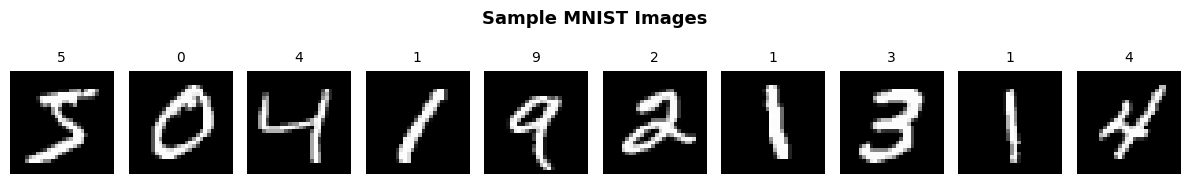

In [22]:
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(str(y_train[i]), fontsize=10)
    plt.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
model_fixed = tf.keras.Sequential([
  tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
  tf.keras.layers.Dense(64,  activation='relu'),
  tf.keras.layers.Dense(10,  activation='softmax')
])

model_fixed.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_fixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
print("\nTraining with Fixed LR...")
history_fixed = model_fixed.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Training with Fixed LR...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8923 - loss: 0.3816 - val_accuracy: 0.9449 - val_loss: 0.1944
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9543 - loss: 0.1578 - val_accuracy: 0.9566 - val_loss: 0.1443
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9681 - loss: 0.1106 - val_accuracy: 0.9665 - val_loss: 0.1154
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9751 - loss: 0.0829 - val_accuracy: 0.9688 - val_loss: 0.1065
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9803 - loss: 0.0656 - val_accuracy: 0.9688 - val_loss: 0.1023
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0519 - val_accuracy: 0.9709 - val_loss: 0.1000
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9868 - loss: 0.0421 - val_accuracy: 0.9740 - val_loss: 0.0920
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9900 - loss

In [26]:
model_adaptive = tf.keras.Sequential([
  tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
  tf.keras.layers.Dense(64,  activation='relu'),
  tf.keras.layers.Dense(10,  activation='softmax')
])

model_adaptive.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Exponential Decay Schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=500,
    decay_rate=0.9
)

# Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [28]:
model_adaptive.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
print("\nTraining with Adaptive LR + Early Stopping...")
history_adaptive = model_adaptive.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Training with Adaptive LR + Early Stopping...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9233 - loss: 0.2483 - val_accuracy: 0.9559 - val_loss: 0.1471
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9644 - loss: 0.1179 - val_accuracy: 0.9612 - val_loss: 0.1285
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0878 - val_accuracy: 0.9698 - val_loss: 0.1043
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9786 - loss: 0.0698 - val_accuracy: 0.9663 - val_loss: 0.1272
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9819 - loss: 0.0564 - val_accuracy: 0.9673 - val_loss: 0.1253
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9861 - loss: 0.0432 - val_accuracy: 0.9689 - val_loss: 0.1350
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9871 - loss: 0.0412 - val_accuracy: 0.9725 - val_loss: 0.1180
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc

In [30]:
loss_f, acc_f = model_fixed.evaluate(X_test, y_test, verbose=0)
loss_a, acc_a = model_adaptive.evaluate(X_test, y_test, verbose=0)

In [32]:
epochs_fixed    = len(history_fixed.history['loss'])
epochs_adaptive = len(history_adaptive.history['loss'])

print(f"\nFixed LR    → Loss: {loss_f:.4f} | Accuracy: {acc_f*100:.2f}% | Epochs: {epochs_fixed}")
print(f"Adaptive LR → Loss: {loss_a:.4f} | Accuracy: {acc_a*100:.2f}% | Epochs: {epochs_adaptive}")


Fixed LR    → Loss: 0.0828 | Accuracy: 97.61% | Epochs: 10
Adaptive LR → Loss: 0.1070 | Accuracy: 96.91% | Epochs: 8


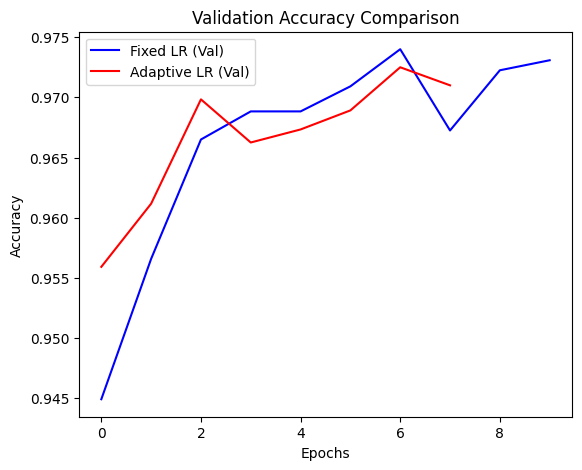

In [38]:
plt.figure(figsize=(14, 5))

# Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history_fixed.history['val_accuracy'], label='Fixed LR (Val)', color='blue')
plt.plot(history_adaptive.history['val_accuracy'], label='Adaptive LR (Val)', color='red')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

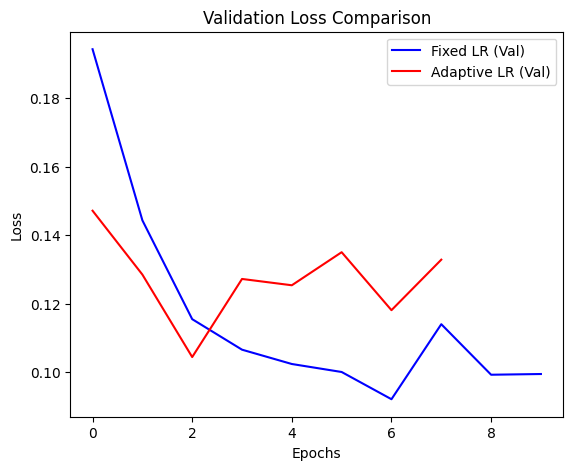

In [37]:
plt.figure(figsize=(14, 5))

# Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history_fixed.history['val_loss'], label='Fixed LR (Val)', color='blue')
plt.plot(history_adaptive.history['val_loss'], label='Adaptive LR (Val)', color='red')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()